In [1]:
"""
Nuclear Chart (Chart of Nuclides)
====================================
Produces:
  - Figure 1.1: Chart of known nuclides from NUBASE2020

Plots all ground-state nuclides from the NUBASE2020 evaluation [Kondev et al.,
Chinese Physics C 45, 030001 (2021)] by neutron number (N) vs. proton number
(Z), classified as stable, radioactive with a directly measured mass, or
radioactive with a mass known only from systematic trends (flagged '#' in
the source file). Neutron magic numbers are marked, with N=126 highlighted
separately as a region of open interest (see Chapter 1).

Data source: nubase2020.txt, the NUBASE2020 ASCII evaluation table, available
from the IAEA Atomic Mass Data Center (https://www-nds.iaea.org/amdc/).
This file is not included in this repository — download it from the AMDC
and place it alongside this notebook before running. (It's a large,
externally-maintained public dataset; better to document the source than
commit a copy that will silently go stale.)
"""

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


def parse_nubase(filepath):
    """Parses ground-state nuclide records from a NUBASE2020 ASCII file.

    Column offsets follow the official NUBASE2020 format specification:
    AAA in cols 1-3, ZZZi (Z + isomer index) in cols 5-8, mass excess in
    cols 19-31 (a '#' anywhere in this field flags a systematics-derived,
    i.e. unmeasured, mass rather than a directly measured one).
    """
    records = []
    with open(filepath, 'r', encoding='utf-8', errors='replace') as f:
        for line in f:
            if line.startswith('#') or not line.strip():
                continue

            A_str = line[0:3].strip()
            ZZZi = line[4:8]
            Z_str = ZZZi[0:3].strip()
            isomer_flag = ZZZi[3:4].strip()
            half_life = line[69:78].strip()
            mass_excess_field = line[18:31]  # columns 19:31, 1-indexed

            if not A_str or not Z_str or isomer_flag != '0':
                continue  # skip isomers/levels, keep ground states only

            try:
                A, Z = int(A_str), int(Z_str)
            except ValueError:
                continue

            records.append({
                'A': A,
                'Z': Z,
                'N': A - Z,
                'stable': half_life == 'stbl',
                'predicted': '#' in mass_excess_field  # mass from systematics, not measured
            })
    return pd.DataFrame(records)


df = parse_nubase('nubase2020.txt')
print(f"Ground-state nuclides: {len(df)}, stable: {df.stable.sum()}, "
      f"predicted/systematics: {df.predicted.sum()}")

Ground-state nuclides: 3558, stable: 253, predicted/systematics: 1008


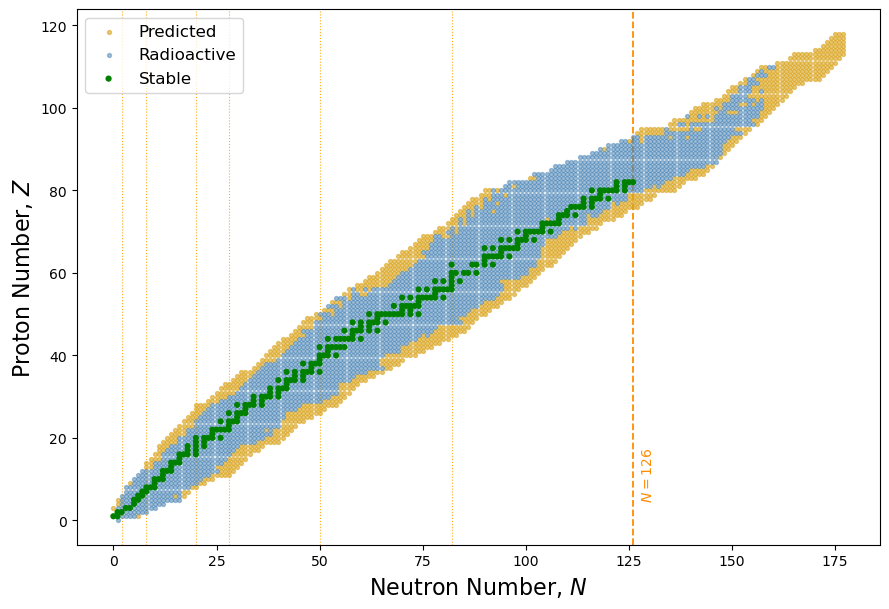

In [2]:
"""
Figure 1.1: Chart of Known Nuclides from NUBASE2020
--------------------------------------------------------
"""

fig, ax = plt.subplots(figsize=(9, 7))
predicted = df[df.predicted & ~df.stable]
radioactive = df[~df.predicted & ~df.stable]
stable = df[df.stable]

ax.scatter(predicted.N, predicted.Z, s=8, color='goldenrod', alpha=0.6,
           label='Predicted', zorder=1)
ax.scatter(radioactive.N, radioactive.Z, s=8, color='steelblue', alpha=0.5,
           label='Radioactive', zorder=2)
ax.scatter(stable.N, stable.Z, s=20, color='green', edgecolor='none',
           label='Stable', zorder=3)

magic_numbers = [2, 8, 20, 28, 50, 82]
for n in magic_numbers:
    ax.axvline(n, color='orange', linestyle=':', linewidth=0.8, alpha=0.9, zorder=0)

ax.axvline(126, color='darkorange', linestyle='--', linewidth=1.3, zorder=0)
ax.text(128, 5, '$N=126$', rotation=90, color='darkorange', fontsize=10)

ax.set_xlabel('Neutron Number, $N$', fontsize=16)
ax.set_ylabel('Proton Number, $Z$', fontsize=16)
ax.set_aspect('equal')
ax.legend(loc='upper left', fontsize=12)
plt.tight_layout()
plt.savefig('nuclear_chart.png', dpi=200)
plt.show()